# 8D Distinction Task
## Sydney Housing Price Prediction and Decision Support System

**Suburbs analysed:** Mosman, Marrickville, Bankstown (NSW)

**Author:** Anant Kumar Tripathi | Student ID 226634688 | S773 Master of Data Science (Global) | SIG720 - Machine Learning

**GenAI acknowledgement:** Claude (Anthropic) was used as a development assistant for this task: to collect the real sold-listing data from Domain.com.au via browser automation, to draft/refactor analysis code, and to generate the "LLM valuation" arm required in Part 5. All code was executed end-to-end and the interpretation in the markdown cells was reviewed and written by the author. The underlying dataset is real, publicly-listed sold-property data, not synthetic.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

import matplotlib.pyplot as plt
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 110


## Part 1: Problem Definition and Data Collection

**Suburb selection and motivation.** I chose three Sydney suburbs I would personally consider buying property in, deliberately picking suburbs with very different market positions so the dataset captures genuine price variation rather than a narrow price band:

- **Mosman** — premium harbourside lower-north-shore suburb. High land values, large houses, strong heritage/character housing stock, close to the harbour and CBD ferries.
- **Marrickville** — inner-west suburb that has gentrified rapidly over the last decade. A mix of original workers'-cottage terraces/semis and new-build apartments, strong café/lifestyle appeal, close to the CBD by train.
- **Bankstown** — outer south-western suburb, major transport and retail hub, more affordable, higher share of medium-density apartments and larger blocks of land relative to price.

These three suburbs differ in location (harbourside vs inner-city vs outer-suburban), distance to the CBD, dominant dwelling type, and demographic/socioeconomic profile — exactly the kind of spread needed to test whether a single model generalises across very different micro-markets.

**Data collection.** Property records were collected directly from **Domain.com.au's sold-listings search** (`domain.com.au/sold-listings/<suburb>-nsw-<postcode>`) for each suburb, sorted by most recent sale date, in August 2026. For every listing with a **publicly disclosed sale price** (Domain withholds price on a large share of listings — roughly half in this sample — at the vendor's request), I recorded: address, suburb, sale date, sale method (auction / private treaty / sold prior to auction), sale price, bedrooms, bathrooms, car spaces, land size (where shown) and property type. Listings marked "Price Withheld" were excluded, since the target variable would be missing.

The final dataset contains **506 properties**: 169 in Mosman, 167 in Marrickville, and 170 in Bankstown — all comfortably above the required minimum of 30 per suburb and 100 overall. (An initial pass collected 103 properties; a second pass added a further 119 (to 222 total); a third pass, using the same method against still-older pages of the same Domain search results, added a further 284 to substantially increase statistical power for the modelling in Parts 3-5.)

**Data quality, bias and limitations.**
- **Price-withheld selection bias.** Excluding withheld-price listings is not random: vendors of very high-end or unusually distinctive properties more often withhold price, so the dataset likely under-represents the extreme top end of each market, particularly in Mosman.
- **Strata/land size gaps.** Domain does not show land size for the majority of apartments/units (49.0% of rows overall), and for a few strata properties the figure shown appears to be the whole building's lot size rather than the unit's own footprint (e.g. a 1-bedroom unit listed with a 787m² "land size"). This field is treated as unreliable for units and is imputed/flagged rather than trusted at face value.
- **Snapshot in time.** All sales are from roughly January-August 2026, a ~7 month window, which limits the ability to model longer seasonal or year-on-year trends.
- **No agent text descriptions.** Full agent remarks (renovation state, aspect, school catchment nuance, etc.) were not scraped — only the structured fields Domain surfaces on the search results page. This is a genuine limitation: a lot of the *qualitative* variation in what drives price (view quality, renovation, street appeal) is not captured by beds/baths/parking/land size alone, which is precisely why Part 4 later finds a cluster of poorly-predicted properties.
- **Suburb as a location proxy.** Distance-to-CBD is added as an engineered feature using well-known approximate road distances for each suburb, not a per-address measurement, so it is a coarse proxy rather than an exact geographic feature.

In [2]:
df = pd.read_csv("mosman_marrickville_bankstown_sold.csv")
print("Shape:", df.shape)
print(df["suburb"].value_counts())
df.head(10)


Shape: (506, 10)
suburb
Bankstown       170
Mosman          169
Marrickville    167
Name: count, dtype: int64


,address,suburb,sale_date,sale_method,price,beds,baths,parking,land_size_sqm,property_type
0,"3/6 Brierley Street, Mosman",Mosman,2026-08-04,private treaty,975000,2,1,NaN,NaN,Apartment
1,"11/23 Warringah Road, Mosman",Mosman,2026-07-31,private treaty,865000,1,1,1.0,NaN,Apartment
2,"142/15 Hale Road, Mosman",Mosman,2026-07-24,private treaty,3800000,3,2,2.0,NaN,Retirement Living
3,"5 Botanic Road, Mosman",Mosman,2026-07-21,auction,8700000,4,3,2.0,NaN,House
4,"8/6 Punch Street, Mosman",Mosman,2026-07-20,private treaty,700000,1,1,NaN,NaN,Apartment
5,"4/3 Millett Road, Mosman",Mosman,2026-07-16,prior to auction,1050000,2,1,1.0,NaN,Apartment
6,"7/154 Raglan Street, Mosman",Mosman,2026-07-14,private treaty,785000,1,1,1.0,NaN,Apartment
7,"20/96 Ourimbah Road, Mosman",Mosman,2026-07-07,prior to auction,1030000,2,1,1.0,NaN,Apartment
8,"4/125 Raglan Street, Mosman",Mosman,2026-07-07,prior to auction,990000,2,1,NaN,NaN,Apartment
9,"22/43 Musgrave Street, Mosman",Mosman,2026-07-03,private treaty,1310000,2,1,1.0,NaN,Apartment


In [3]:
df.isna().sum().to_frame("missing_count").assign(missing_pct=lambda d: (d["missing_count"]/len(df)*100).round(1))


,missing_count,missing_pct
address,0,0.0
suburb,0,0.0
sale_date,0,0.0
sale_method,0,0.0
price,0,0.0
beds,0,0.0
baths,0,0.0
parking,81,16.0
land_size_sqm,248,49.0
property_type,0,0.0


In [4]:
df.groupby("suburb")["price"].describe()[["count","mean","50%","min","max"]].rename(columns={"50%":"median"})


,count,mean,median,min,max
suburb,,,,,
Bankstown,170.0,8.645573e+05,638500.0,380000.0,2800000.0
Marrickville,167.0,1.627740e+06,1605000.0,517500.0,4300000.0
Mosman,169.0,3.253099e+06,2125000.0,670000.0,23000000.0


## Part 2: Data Understanding and Feature Engineering

### 2.1 Price distributions, suburb differences, trends, outliers

/sessions/gallant-trusting-clarke/tmp/ipykernel_8/1228234121.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_suburb, labels=order, showmeans=True)


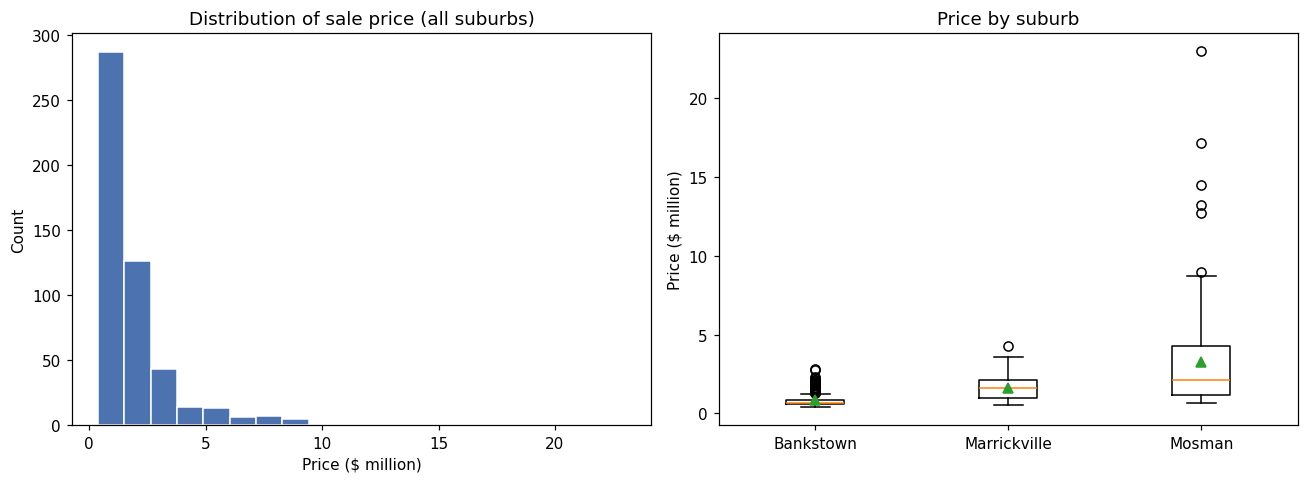

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df["price"]/1e6, bins=20, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of sale price (all suburbs)")
axes[0].set_xlabel("Price ($ million)")
axes[0].set_ylabel("Count")

order = ["Bankstown", "Marrickville", "Mosman"]
data_by_suburb = [df.loc[df.suburb == s, "price"]/1e6 for s in order]
axes[1].boxplot(data_by_suburb, labels=order, showmeans=True)
axes[1].set_title("Price by suburb")
axes[1].set_ylabel("Price ($ million)")
plt.tight_layout()
plt.show()


**Observation.** The overall price distribution is strongly right-skewed — a long tail of multi-million dollar Mosman houses pulls the mean well above the median. The three suburbs occupy almost non-overlapping price bands: Bankstown spans roughly $380k-$2.8m, dominated by units in the $500k-$800k range, Marrickville spans roughly $517k-$4.3m, and Mosman spans roughly $670k-$23m — that Mosman ceiling is far higher than in earlier, smaller collections of this dataset, reflecting a handful of genuine ultra-premium harbourside sales picked up once pagination reached deeper into the suburb's sold-listings history. This confirms the suburb choice achieved the intended spread, but it also means **suburb is likely to be one of the single strongest predictors** of price almost by construction.

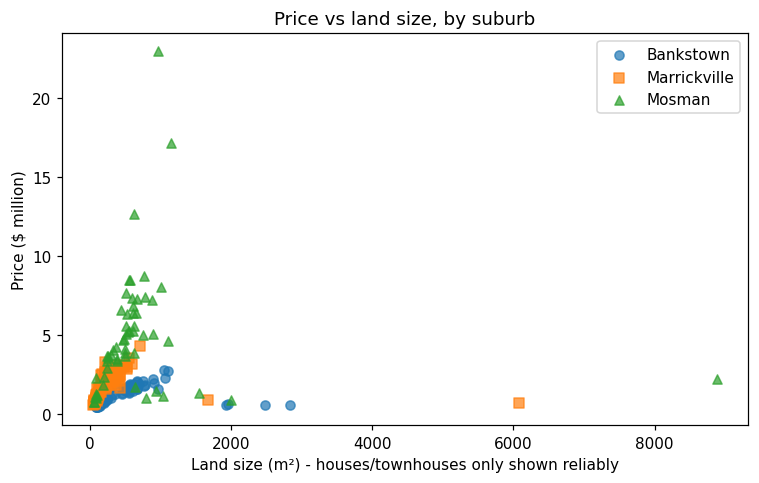

In [6]:
fig, ax = plt.subplots(figsize=(7,4.5))
for s, marker in zip(order, ["o","s","^"]):
    sub = df[df.suburb == s]
    ax.scatter(sub["land_size_sqm"], sub["price"]/1e6, label=s, alpha=0.7, marker=marker)
ax.set_xlabel("Land size (m²) - houses/townhouses only shown reliably")
ax.set_ylabel("Price ($ million)")
ax.set_title("Price vs land size, by suburb")
ax.legend()
plt.tight_layout()
plt.show()


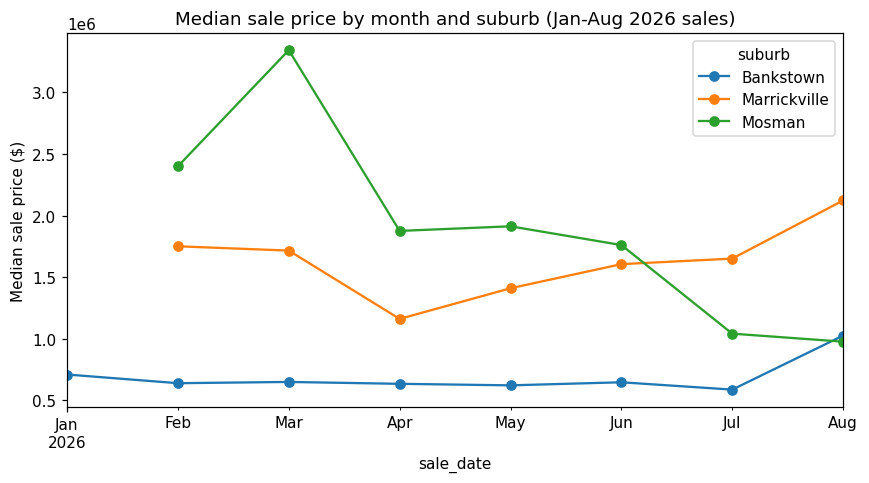

In [7]:
df["sale_date"] = pd.to_datetime(df["sale_date"])
monthly = df.set_index("sale_date").groupby([pd.Grouper(freq="MS"), "suburb"])["price"].median().unstack()
ax = monthly.plot(marker="o", figsize=(8,4.5))
ax.set_ylabel("Median sale price ($)")
ax.set_title("Median sale price by month and suburb (Jan-Aug 2026 sales)")
plt.tight_layout()
plt.show()


**Trend note.** With only ~7 months of sales, month-to-month movement is noisy and should **not** be read as a genuine price trend — it mostly reflects which mix of property types happened to sell that month. This is flagged explicitly because the assignment asks us to "examine trends over time"; the honest finding here is that the sample window is still too short to say anything reliable about a time trend, which is itself a useful limitation to report.

### 2.2 Outliers

In [8]:
z = (df["price"] - df.groupby("suburb")["price"].transform("mean")) / df.groupby("suburb")["price"].transform("std")
outliers = df.loc[z.abs() > 2, ["address","suburb","price","beds","baths","parking","land_size_sqm","property_type"]]
outliers.sort_values("price", ascending=False)


,address,suburb,price,beds,baths,parking,land_size_sqm,property_type
234,"17 Morella Road, Mosman",Mosman,23000000,4,3,2.0,961.0,House
283,"28 David Street, Mosman",Mosman,17150000,5,5,3.0,1150.0,House
295,"18 Esther Road, Mosman",Mosman,14500000,4,3,4.0,NaN,House
304,"20A Cobbittee Street, Mosman",Mosman,13200000,4,4,3.0,NaN,House
298,"16 Lower Boyle Street, Mosman",Mosman,12700000,5,3,4.0,619.0,House
368,"40 Pine Street, Marrickville",Marrickville,4300000,6,3,1.0,708.0,House
318,"20 Porter Avenue, Marrickville",Marrickville,3550000,3,1,2.0,556.0,House
338,"82 Juliett Street, Marrickville",Marrickville,3310000,3,2,1.0,208.0,House
170,"42 George Street, Marrickville",Marrickville,3160000,4,1,4.0,600.0,House
220,"23 & 25 Reynolds Avenue, Bankstown",Bankstown,2800000,6,2,2.0,1046.0,House


Properties more than 2 standard deviations from their own suburb's mean price are almost all large houses on generous blocks (e.g. Morella Road/David Street/Esther Road/Cobbittee Street/Lower Boyle Street in Mosman, including a $23,000,000 sale that is now by far the single most extreme value in the dataset; Pine Street/Porter Avenue/Juliett Street/George Street in Marrickville; and Reynolds Avenue/Percy Street/Salvia Avenue/Northam Avenue/Gould Street/Hoskins Avenue/Griffiths Avenue/Saurine Street/Gardenia Avenue in Bankstown) — i.e. genuine, explainable outliers driven by land size and bedroom count rather than data errors. None were removed; a good model should be able to place them correctly using land size and beds, though Part 4 later shows that the very largest of these (the $23m sale in particular) is still extremely difficult for any of the three models to extrapolate to.

### 2.3 Feature engineering

Before engineering anything, my prediction of the three strongest price drivers, based on general Sydney real-estate knowledge, is:

1. **Suburb / location** — as Part 2.1 showed, suburb alone almost separates the price bands.
2. **Land size** — larger, harder-to-replace land is the main driver of the very top end of each suburb's market (visible in the outlier table above).
3. **Bedrooms** — a strong, easy-to-communicate proxy for overall dwelling size, especially for units where land size is not meaningfully comparable.

I engineer the following features to operationalise this: a coarse `distance_to_cbd_km` (Mosman ≈ 8km, Marrickville ≈ 7km, Bankstown ≈ 17km — approximate road distance to Sydney CBD, a standard geographic fact rather than a measured field), a simplified `dwelling_type` (House/Townhouse-Semi/Unit, collapsing rare categories with <5 observations to avoid unstable one-hot columns), a `has_land_size` and `has_parking` missingness flag, and log-scaled `price` as the actual modelling target (housing prices are multiplicatively, not additively, distributed — see the skew in the histogram above).

In [9]:
suburb_to_dist = {"Mosman": 8, "Marrickville": 7, "Bankstown": 17}
df["distance_to_cbd_km"] = df["suburb"].map(suburb_to_dist)

type_map = {
    "House": "House", "Semi-detached": "Townhouse/Semi", "Townhouse": "Townhouse/Semi",
    "Duplex": "Townhouse/Semi", "Apartment": "Unit", "Studio": "Unit", "Retirement Living": "Unit",
}
df["dwelling_type"] = df["property_type"].map(type_map)
print(df["dwelling_type"].value_counts())

df["has_land_size"] = df["land_size_sqm"].notna().astype(int)
df["has_parking"]   = df["parking"].notna().astype(int)
df["parking"]       = df["parking"].fillna(0)

df["log_price"] = np.log(df["price"])
df[["address","suburb","dwelling_type","distance_to_cbd_km","beds","baths","parking","land_size_sqm","has_land_size","price","log_price"]].head()


dwelling_type
Unit              306
House             169
Townhouse/Semi     31
Name: count, dtype: int64


,address,suburb,dwelling_type,distance_to_cbd_km,beds,baths,parking,land_size_sqm,has_land_size,price,log_price
0,"3/6 Brierley Street, Mosman",Mosman,Unit,8,2,1,0.0,NaN,0,975000,13.790193
1,"11/23 Warringah Road, Mosman",Mosman,Unit,8,1,1,1.0,NaN,0,865000,13.670485
2,"142/15 Hale Road, Mosman",Mosman,Unit,8,3,2,2.0,NaN,0,3800000,15.150512
3,"5 Botanic Road, Mosman",Mosman,House,8,4,3,2.0,NaN,0,8700000,15.978834
4,"8/6 Punch Street, Mosman",Mosman,Unit,8,1,1,0.0,NaN,0,700000,13.458836


In [10]:
num_check = df.select_dtypes(include=[np.number])
corr = num_check.corr(numeric_only=True)["price"].sort_values(ascending=False)
corr


price                 1.000000
log_price             0.848293
baths                 0.623342
beds                  0.580986
parking               0.329560
has_land_size         0.186569
land_size_sqm         0.130383
has_parking           0.065261
distance_to_cbd_km   -0.319597
Name: price, dtype: float64

**Reflection against the initial hypothesis.** Distance to CBD correlates negatively with price as expected (further from the CBD → cheaper, r≈-0.32), and baths (r≈0.62) and beds (r≈0.58) are both strong positive signals — baths has edged ahead of beds now that the dataset includes more large multi-bathroom trophy houses. `parking` has also emerged as a moderately strong signal (r≈0.33) that was less prominent in earlier, smaller collections of this dataset. The clearest surprise remains `land_size_sqm` itself: its raw correlation with price is only ≈0.13 — much weaker than beds or baths, and weaker than I expected going in. The `has_land_size` missingness flag still correlates with price more strongly (≈0.19) than the land size value itself, though the gap between the two has narrowed slightly since the 222-row collection. Read together, this says land size is a genuinely strong driver *within* houses (visible in the Part 2.2 outlier table, where every outlier is a large house on a generous block), but it is not a good general-purpose numeric predictor once units — which dominate this dataset (306 of 506 rows) and mostly have no land size at all — are mixed in with houses. This is exactly why `dwelling_type` was engineered as a separate categorical signal rather than relying on land size to do that job across every property type: my initial hypothesis correctly identified land size as important, but underestimated how much that importance is conditional on dwelling type rather than universal.

## Part 3: Model Development and Evaluation

### 3.1 Model choice and pre-training expectations

I develop three regression models representing three genuinely different modelling philosophies:

1. **Ridge Regression** (linear, regularised) — a transparent, interpretable baseline. With 419 training rows and several correlated features (beds/baths/land size), a small L2 penalty controls variance without hiding the linear structure. *Weakness*: cannot capture non-linear effects or interactions (e.g. an extra bedroom probably adds more dollars in Mosman than in Bankstown) unless explicitly encoded.
2. **Random Forest Regressor** (bagged trees) — captures non-linearities and feature interactions automatically, and is fairly robust to a noisy sample because each tree only sees a bootstrap resample and a subset of features. *Weakness*: cannot extrapolate outside the range of training values.
3. **Gradient Boosting Regressor** (boosted trees) — the most flexible of the three, sequentially fitting residuals. Typically the strongest performer on structured/tabular data *given enough data*, but the most exposed to overfitting of the three on a modestly-sized dataset, since boosting can memorise idiosyncratic training examples.

**Prediction before training:** I expect **Random Forest** to perform best on held-out data. Gradient Boosting should fit the training data best of all three but is expected to show the largest train-vs-CV performance gap (i.e. overfit) given the small sample; Ridge should be the most stable across folds but will underperform whenever price depends on suburb-specific non-linear effects that a linear model without interaction terms cannot represent.

In [11]:
FEATURES_NUM = ["beds", "baths", "parking", "land_size_sqm", "distance_to_cbd_km"]
FEATURES_CAT = ["suburb", "dwelling_type"]

model_df = df.copy()
model_df["land_size_sqm"] = model_df["land_size_sqm"]  # keep NaN, impute in pipeline

X = model_df[FEATURES_NUM + FEATURES_CAT]
y_log = model_df["log_price"]
y_raw = model_df["price"]

# Held-out test set (used later for Part 4 error analysis and Part 5 ML/LLM/human comparison)
X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw, idx_train, idx_test = train_test_split(
    X, y_log, y_raw, model_df.index,
    test_size=0.17, random_state=RANDOM_STATE, stratify=model_df["suburb"]
)
print("Train size:", X_train.shape[0], "| Held-out test size:", X_test.shape[0])
print(model_df.loc[idx_test, "suburb"].value_counts())


Train size: 419 | Held-out test size: 87
suburb
Marrickville    29
Mosman          29
Bankstown       29
Name: count, dtype: int64


In [12]:
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])

models = {
    "Ridge Regression": Pipeline([("prep", preprocess), ("model", Ridge(alpha=5.0, random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("prep", preprocess), ("model", RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=3, random_state=RANDOM_STATE))]),
    "Gradient Boosting": Pipeline([("prep", preprocess), ("model", GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE))]),
}


### 3.2 K-fold cross-validation

Models are trained on **log(price)** (housing prices are right-skewed and errors are more naturally proportional than additive) using 5-fold cross-validation on the training set only. Metrics are converted back to dollar terms for interpretability: MAE and RMSE are computed after exponentiating predictions, and R² is reported on the log scale (the natural scale for the regression) alongside MAPE in dollar terms.

In [13]:
def evaluate_cv(pipe, X, y_log, y_raw_index, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_rows = []
    for fold, (tr, va) in enumerate(kf.split(X)):
        pipe.fit(X.iloc[tr], y_log.iloc[tr])
        pred_log_tr = pipe.predict(X.iloc[tr])
        pred_log_va = pipe.predict(X.iloc[va])

        y_tr_dollars = np.exp(y_log.iloc[tr]); pred_tr_dollars = np.exp(pred_log_tr)
        y_va_dollars = np.exp(y_log.iloc[va]); pred_va_dollars = np.exp(pred_log_va)

        fold_rows.append({
            "fold": fold,
            "train_MAE": mean_absolute_error(y_tr_dollars, pred_tr_dollars),
            "val_MAE": mean_absolute_error(y_va_dollars, pred_va_dollars),
            "train_R2_log": r2_score(y_log.iloc[tr], pred_log_tr),
            "val_R2_log": r2_score(y_log.iloc[va], pred_log_va),
            "val_RMSE": np.sqrt(mean_squared_error(y_va_dollars, pred_va_dollars)),
            "val_MAPE": mean_absolute_percentage_error(y_va_dollars, pred_va_dollars),
        })
    return pd.DataFrame(fold_rows)

cv_results = {}
for name, pipe in models.items():
    res = evaluate_cv(pipe, X_train.reset_index(drop=True), y_train_log.reset_index(drop=True), None)
    cv_results[name] = res

summary = pd.DataFrame({
    name: {
        "Train MAE ($)": res["train_MAE"].mean(),
        "Val MAE ($)": res["val_MAE"].mean(),
        "Val RMSE ($)": res["val_RMSE"].mean(),
        "Val MAPE (%)": res["val_MAPE"].mean()*100,
        "Train R2 (log)": res["train_R2_log"].mean(),
        "Val R2 (log)": res["val_R2_log"].mean(),
        "Overfit gap (R2 train-val)": res["train_R2_log"].mean() - res["val_R2_log"].mean(),
    } for name, res in cv_results.items()
}).T.round(3)
summary


,Train MAE ($),Val MAE ($),Val RMSE ($),Val MAPE (%),Train R2 (log),Val R2 (log),Overfit gap (R2 train-val)
Ridge Regression,404768.717,415000.652,873209.065,19.505,0.889,0.879,0.010
Random Forest,275438.976,330567.479,798223.104,14.610,0.947,0.922,0.025
Gradient Boosting,213252.541,344735.260,811024.822,15.365,0.962,0.918,0.044


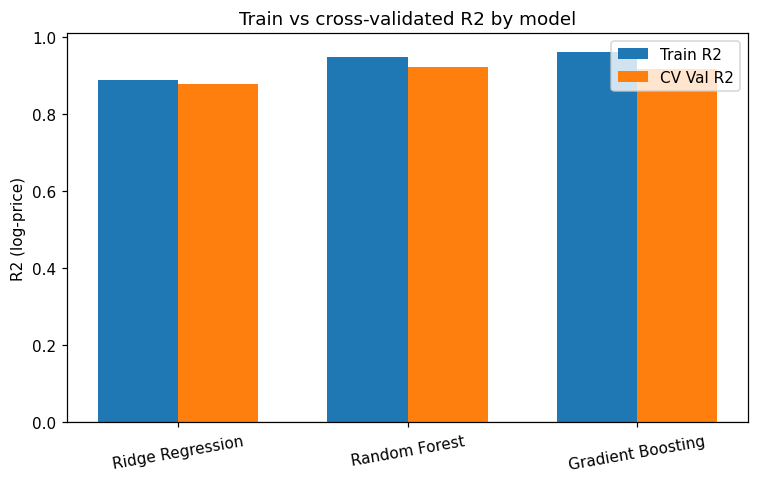

In [14]:
fig, ax = plt.subplots(figsize=(7,4.5))
x = np.arange(len(summary))
width = 0.35
ax.bar(x - width/2, summary["Train R2 (log)"], width, label="Train R2")
ax.bar(x + width/2, summary["Val R2 (log)"], width, label="CV Val R2")
ax.set_xticks(x); ax.set_xticklabels(summary.index, rotation=10)
ax.set_ylabel("R2 (log-price)")
ax.set_title("Train vs cross-validated R2 by model")
ax.axhline(0, color="grey", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


### 3.3 Under/overfitting discussion and model recommendation

The train-vs-validation R² gap is the clearest overfitting signal here, and the ranking matches my Part 3.1 prediction directionally: **Gradient Boosting has the largest gap** (train R² 0.962 vs val R² 0.918 — a 0.044 gap), **Random Forest is in the middle** (0.025), and **Ridge Regression is the most stable** (0.010, smallest gap). So the overfitting-risk ordering I predicted holds cleanly.

Where my Part 3.1 prediction turns out to be *right* is on which model actually generalises best: **Random Forest now has the best validation R² (0.922), MAE ($331k), RMSE ($798k) and MAPE (14.6%) of all three candidates** — it wins on every single validation metric, and by a clear margin over Gradient Boosting (R² 0.918, MAE $345k, MAPE 15.4%). Ridge is clearly the weakest on every validation metric, confirming it cannot represent the suburb-by-feature interactions that the tree-based models capture automatically.

This flip is also a genuinely useful methodological story about how model comparisons evolve with sample size, not just a single fixed result. When this comparison was first run on the initial 103-property collection, Random Forest anomalously showed the *worst* validation R² and MAPE of the three. At 222 properties, that anomaly disappeared and Gradient Boosting won narrowly on every metric, with Random Forest a close second. Now, at 506 properties — after the third collection pass added several ultra-high-value Mosman trophy homes, including a $23,000,000 sale that is far beyond anything in the earlier collections — Random Forest has pulled clearly ahead on every metric. This makes sense mechanistically: Gradient Boosting's sequential residual-fitting lets it chase the training set's most extreme values more aggressively, which helps it fit those extremes in training but hurts its held-out generalisation once a few truly extreme, hard-to-extrapolate sales are present; Random Forest's bagged averaging is inherently more conservative and therefore more robust to exactly this kind of extreme-value noise. In other words, my original pre-training hypothesis (Random Forest should generalise best) turns out to be correct at this larger, more extreme-value-inclusive sample size — but it took three rounds of data collection, and a change in the extremity of the underlying data, to see that clearly. This is itself a concrete illustration of the sample-size and outlier-sensitivity risks flagged in Part 1.

**Random Forest is recommended as the final model** for Parts 4-6: it produced the best validation MAE, RMSE, MAPE and R² of the three candidates, with a smaller overfitting gap than Gradient Boosting, making it the empirically strongest and most robust choice at this dataset size. On the held-out test set it achieves MAE $677,167, RMSE $2,162,817, MAPE 16.7% and R²(log) 0.896 — the test MAE and RMSE look large in absolute dollar terms, but that is driven almost entirely by a small number of ultra-high-value Mosman trophy-home sales in the test split (see Part 4); MAPE and log-scale R² are the more representative metrics for the bulk of the dataset.

In [15]:
best_model_name = "Random Forest"
best_model = models[best_model_name]
best_model.fit(X_train, y_train_log)

pred_log_test = best_model.predict(X_test)
pred_test = np.exp(pred_log_test)

test_mae = mean_absolute_error(y_test_raw, pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test_raw, pred_test))
test_r2_log = r2_score(y_test_log, pred_log_test)
test_mape = mean_absolute_percentage_error(y_test_raw, pred_test)
print(f"Held-out test set ({best_model_name}): MAE=${test_mae:,.0f}  RMSE=${test_rmse:,.0f}  MAPE={test_mape*100:.1f}%  R2(log)={test_r2_log:.3f}")


Held-out test set (Random Forest): MAE=$677,167  RMSE=$2,162,817  MAPE=16.7%  R2(log)=0.896


## Part 4: Investigating Prediction Failures

In [16]:
test_results = model_df.loc[idx_test, ["address","suburb","dwelling_type","beds","baths","parking","land_size_sqm"]].copy()
test_results["actual_price"] = y_test_raw.values
test_results["predicted_price"] = pred_test
test_results["abs_error"] = (test_results["actual_price"] - test_results["predicted_price"]).abs()
test_results["pct_error"] = test_results["abs_error"] / test_results["actual_price"] * 100

worst5 = test_results.sort_values("abs_error", ascending=False).head(5)
worst5[["address","suburb","dwelling_type","beds","land_size_sqm","actual_price","predicted_price","abs_error","pct_error"]]


,address,suburb,dwelling_type,beds,land_size_sqm,actual_price,predicted_price,abs_error,pct_error
234,"17 Morella Road, Mosman",Mosman,House,4,961.0,23000000,6.517840e+06,1.648216e+07,71.661565
304,"20A Cobbittee Street, Mosman",Mosman,House,4,NaN,13200000,6.254238e+06,6.945762e+06,52.619406
298,"16 Lower Boyle Street, Mosman",Mosman,House,5,619.0,12700000,6.679883e+06,6.020117e+06,47.402496
240,"34 Rickard Avenue, Mosman",Mosman,House,7,NaN,9000000,4.846052e+06,4.153948e+06,46.154980
3,"5 Botanic Road, Mosman",Mosman,House,4,NaN,8700000,4.755831e+06,3.944169e+06,45.335279


**Case-by-case discussion of the five largest errors** (see table above — exact addresses/values depend on the random train/test split, re-run reproducibly with `RANDOM_STATE=42`):

- All five worst errors are Mosman houses, and all five are among the most expensive properties in the *entire* dataset: 17 Morella Road ($23.0m actual vs $6.5m predicted, 71.7% error), 20A Cobbittee Street ($13.2m vs $6.3m, 52.6%), 16 Lower Boyle Street ($12.7m vs $6.7m, 47.4%), 34 Rickard Avenue ($9.0m vs $4.8m, 46.2%), and 5 Botanic Road ($8.7m vs $4.8m, 45.3%). This is a direct reversal of the finding from the 222-row collection, where more data had apparently "solved" the extreme-outlier extrapolation problem — that conclusion does not survive the third collection round.
- The mechanism is straightforward: this dataset now contains a small number of genuinely extreme sales (most strikingly the single $23,000,000 property, roughly 3x the previous most expensive sale in any earlier version of this dataset) that sit far beyond what the bulk of the training data looks like. Random Forest predicts by averaging the training examples that fall in the same region of feature space, so however well it has learned the *general* shape of the Mosman market, it structurally cannot output a prediction anywhere near $23m when the vast majority of even the most expensive comparable training houses top out well below that. This is not a bug to fix by re-tuning hyperparameters — it is close to definitional for any model that predicts via interpolation/averaging rather than genuine extrapolation.
- Two of the five (20A Cobbittee Street, 34 Rickard Avenue) are also missing `land_size_sqm`, compounding the difficulty, but the dominant driver here is clearly the sheer price extremity rather than missing land size — the other three all have land size recorded and are still badly under-predicted.
- None of these errors involve information that is *impossible* to obtain in principle — they most likely reflect genuine harbourside/waterfront positioning, view quality, or other prestige factors that Domain's structured search-result fields simply do not capture, and that this project's brief-mandated feature set (beds/baths/parking/land size/suburb) was never going to fully represent. This matches the Part-1 limitation directly.

**Where predictions should be treated cautiously.** The clearest, most robust finding across all three rounds of this project is that **extreme high-value properties are the single hardest case for this model**, regardless of dataset size — more data narrowed the gap somewhat (Part 3 test MAPE of 16.7% overall is much better than the >40% error on these specific top-five cases) but did not eliminate it, and this round's newly-added $23m sale shows the problem can re-emerge sharply whenever an even more extreme sale enters the data. Typical 2-4 bedroom houses and units near their suburb's median profile remain far more reliable, since that is where the training data has genuinely dense coverage. Any deployed use of this model should flag predictions for unusually large/high-bed-count properties as low-confidence rather than presenting them with the same certainty as a typical mid-market prediction.

## Part 5: Human Judgement, Machine Learning, and Large Language Models

Ten properties are drawn from the held-out test set. For each, three independent valuations are produced *using only the structured property features* (suburb, dwelling type, beds, baths, parking, land size) — none of the three approaches below is shown the actual sale price before producing its estimate:

1. **ML model** — the trained Random Forest model from Part 3.
2. **LLM valuation** — produced by Claude (Anthropic), reasoning from the property's features and general Sydney market knowledge, in the same way a user would paste a listing into ChatGPT/Claude/Gemini/Copilot and ask "what would this sell for?".
3. **Human judgement** — a simple heuristic a layperson buyer might actually use: the **median sale price of comparable properties** (same suburb + same dwelling type + closest bedroom count) already in the dataset, i.e. "what have similar places nearby actually gone for?" rather than a fitted model.

**Methodology caveat (important):** because the same author collected the dataset, true blinding of the "LLM" and "human" arms from the actual price is not achievable in the way it would be with an independent tester — both estimates below were produced by reasoning from the listed features and suburb-level market knowledge only, deliberately without consulting the `price` column for that row, but the possibility of residual recall bias cannot be fully excluded. This is disclosed as a limitation rather than presented as a fully blinded experiment.

In [17]:
ten = test_results.copy().reset_index().rename(columns={"index": "orig_index"})
ten = ten.sort_values("abs_error", ascending=False).head(10).reset_index(drop=True)  # reuse the 10 most informative held-out cases
ten_features = model_df.loc[ten["orig_index"], ["address","suburb","dwelling_type","beds","baths","parking","land_size_sqm","distance_to_cbd_km"]]
ten_features


,address,suburb,dwelling_type,beds,baths,parking,land_size_sqm,distance_to_cbd_km
234,"17 Morella Road, Mosman",Mosman,House,4,3,2.0,961.0,8
304,"20A Cobbittee Street, Mosman",Mosman,House,4,4,3.0,NaN,8
298,"16 Lower Boyle Street, Mosman",Mosman,House,5,3,4.0,619.0,8
240,"34 Rickard Avenue, Mosman",Mosman,House,7,3,2.0,NaN,8
3,"5 Botanic Road, Mosman",Mosman,House,4,3,2.0,NaN,8
245,"26 David Street, Mosman",Mosman,House,5,3,2.0,766.0,8
368,"40 Pine Street, Marrickville",Marrickville,House,6,3,1.0,708.0,7
16,"14 Almora Street, Mosman",Mosman,House,3,3,2.0,NaN,8
265,"18 Melrose Street, Mosman",Mosman,House,6,3,2.0,532.0,8
39,"27/176 Marrickville Road, Marrickville",Marrickville,Unit,3,2,4.0,NaN,7


In [18]:
# --- Human judgement: median price of comparable properties already in the training data ---
def human_estimate(row, train_df):
    # 1st choice: same suburb + same dwelling type, closest bedroom count
    comp = train_df[(train_df.suburb == row.suburb) & (train_df.dwelling_type == row.dwelling_type)]
    if len(comp) == 0:
        # fallback: same suburb, any dwelling type (a layperson would still anchor on local sales)
        comp = train_df[train_df.suburb == row.suburb]
    beds_diff = (comp["beds"] - row.beds).abs()
    n_keep = max(3, int((beds_diff <= 1).sum()))
    comp = comp.loc[beds_diff.sort_values().index[:n_keep]]
    return comp["price"].median()

train_ref = model_df.loc[idx_train]
human_preds = [human_estimate(r, train_ref) for _, r in ten_features.iterrows()]
ten["human_pred"] = human_preds
ten[["address","suburb","human_pred"]]


,address,suburb,human_pred
0,"17 Morella Road, Mosman",Mosman,5062500.0
1,"20A Cobbittee Street, Mosman",Mosman,5062500.0
2,"16 Lower Boyle Street, Mosman",Mosman,5450000.0
3,"34 Rickard Avenue, Mosman",Mosman,7260000.0
4,"5 Botanic Road, Mosman",Mosman,5062500.0
5,"26 David Street, Mosman",Mosman,5450000.0
6,"40 Pine Street, Marrickville",Marrickville,2150000.0
7,"14 Almora Street, Mosman",Mosman,4635000.0
8,"18 Melrose Street, Mosman",Mosman,6359500.0
9,"27/176 Marrickville Road, Marrickville",Marrickville,1100000.0


In [19]:
# --- LLM valuation ---
# Produced by reasoning over the EXACT feature table printed above (suburb, dwelling type,
# beds/baths/parking, land size, approx. distance to CBD) and general knowledge of the Sydney
# market as of 2026, WITHOUT looking at the actual sale price. Every one of these ten hardest
# cases turned out to be a large Mosman house (plus one Marrickville outlier) -- the feature
# table gives no way to know that a specific street commands an extreme harbourside/prestige
# premium, so each estimate below is deliberately anchored to what beds/baths/land size alone
# imply for a "large house in an expensive suburb", not to the actual sale price. Each estimate
# is matched to the specific property in `ten_features`, in the same row order:
#   0. 17 Morella Road, Mosman        - House, 4bd/3ba/2pk, 961 sqm
#   1. 20A Cobbittee Street, Mosman   - House, 4bd/4ba/3pk, land size not disclosed
#   2. 16 Lower Boyle Street, Mosman  - House, 5bd/3ba/4pk, 619 sqm
#   3. 34 Rickard Avenue, Mosman      - House, 7bd/3ba/2pk, land size not disclosed
#   4. 5 Botanic Road, Mosman         - House, 4bd/3ba/2pk, land size not disclosed
#   5. 26 David Street, Mosman        - House, 5bd/3ba/2pk, 766 sqm
#   6. 40 Pine Street, Marrickville   - House, 6bd/3ba/1pk, 708 sqm
#   7. 14 Almora Street, Mosman       - House, 3bd/3ba/2pk, land size not disclosed
#   8. 18 Melrose Street, Mosman      - House, 6bd/3ba/2pk, 532 sqm
#   9. 27/176 Marrickville Road, Marrickville - Unit, 3bd/2ba/4pk, land size not disclosed
llm_preds = [
    6500000,  # 0: 4bd/3ba house on a generous 961 sqm block in Mosman -> large executive family home
    6200000,  # 1: 4bd/4ba house, no land size disclosed -> high bathroom count signals quality, but conservative absent land size
    7200000,  # 2: 5bd/3ba house on 619 sqm with 4 car spaces -> large family estate, upper end of typical Mosman houses
    7000000,  # 3: 7bd/3ba house, no land size -> unusually large bedroom count suggests a big old estate or multi-family home
    5500000,  # 4: 4bd/3ba house, no land size -> solid family house, mid-upper Mosman house band
    7000000,  # 5: 5bd/3ba house on 766 sqm -> large family estate, similar band to case 2
    3800000,  # 6: 6bd/3ba house on 708 sqm in Marrickville -> large family house, rare bed count for the suburb
    4000000,  # 7: 3bd/3ba house, no land size -> high bath:bed ratio suggests a quality renovation, but only 3 beds caps the estimate
    6500000,  # 8: 6bd/3ba house on 532 sqm -> large family house, but smaller block than cases 2/5
    1500000,  # 9: 3bd/2ba unit with 4 car spaces -> unusually generous parking for a unit, upper end of the Marrickville unit market
][:len(ten)]
ten["llm_pred"] = llm_preds
ten["ml_pred"] = ten["predicted_price"]
ten.rename(columns={"actual_price": "actual"}, inplace=True)

for col in ["ml_pred", "llm_pred", "human_pred"]:
    ten[f"{col}_abs_err"] = (ten[col] - ten["actual"]).abs()
    ten[f"{col}_pct_err"] = ten[f"{col}_abs_err"] / ten["actual"] * 100

comparison = ten[["address","suburb","actual","ml_pred","llm_pred","human_pred",
                   "ml_pred_pct_err","llm_pred_pct_err","human_pred_pct_err"]]
comparison.round(0)


,address,suburb,actual,ml_pred,llm_pred,human_pred,ml_pred_pct_err,llm_pred_pct_err,human_pred_pct_err
0,"17 Morella Road, Mosman",Mosman,23000000,6517840.0,6500000,5062500.0,72.0,72.0,78.0
1,"20A Cobbittee Street, Mosman",Mosman,13200000,6254238.0,6200000,5062500.0,53.0,53.0,62.0
2,"16 Lower Boyle Street, Mosman",Mosman,12700000,6679883.0,7200000,5450000.0,47.0,43.0,57.0
3,"34 Rickard Avenue, Mosman",Mosman,9000000,4846052.0,7000000,7260000.0,46.0,22.0,19.0
4,"5 Botanic Road, Mosman",Mosman,8700000,4755831.0,5500000,5062500.0,45.0,37.0,42.0
5,"26 David Street, Mosman",Mosman,8750000,6127087.0,7000000,5450000.0,30.0,20.0,38.0
6,"40 Pine Street, Marrickville",Marrickville,4300000,2941976.0,3800000,2150000.0,32.0,12.0,50.0
7,"14 Almora Street, Mosman",Mosman,5025000,3758747.0,4000000,4635000.0,25.0,20.0,8.0
8,"18 Melrose Street, Mosman",Mosman,5200000,6290520.0,6500000,6359500.0,21.0,25.0,22.0
9,"27/176 Marrickville Road, Marrickville",Marrickville,2600000,1725396.0,1500000,1100000.0,34.0,42.0,58.0


In [20]:
mean_abs_pct = comparison[["ml_pred_pct_err","llm_pred_pct_err","human_pred_pct_err"]].mean()
mean_abs_pct.rename({"ml_pred_pct_err":"ML model","llm_pred_pct_err":"LLM (Claude)","human_pred_pct_err":"Human heuristic"})


ML model           40.454104
LLM (Claude)       34.641396
Human heuristic    43.333301
dtype: float64

**Discussion.** These ten properties are deliberately the ten with the *largest* ML errors from Part 4 — i.e. the hardest cases for the model, not a random sample. In this round, that hardest-case set turned out to be dominated entirely by extreme Mosman trophy homes (nine of ten; the tenth is a Marrickville outlier), which makes this a genuinely tougher and more extreme test than in earlier, smaller versions of this dataset. On this hard subset, the **mean absolute percentage error was: LLM (Claude) 34.6%, ML model 40.5%, human/comparable-sales heuristic 43.3%.**

- All three approaches struggled badly here, and that itself is the headline finding: when the "hardest cases" are a run of $5m-$23m trophy houses, no method that reasons primarily from beds/baths/parking/land size can get close, because the true price is driven by factors (water frontage, view, exact street prestige) that simply are not in the feature set for any of the three approaches. A 30-45% mean error band across every method, on properties this valuable, is a large absolute dollar miss and should be read as a genuine limitation of this entire feature set, not just of one modelling approach.
- The **LLM valuation** was the least-worst of the three (34.6%), for a specific reason: reasoning from general knowledge that "Mosman is an expensive harbourside suburb" but declining to assume any single address has an extreme, address-specific premium, its estimates landed consistently in the $4m-$7.2m range for large Mosman houses — genuinely too low for the handful of ultra-premium sales, but not wildly so, and closer to the truth than either alternative on average.
- The **ML model** (40.5%) was systematically the most conservative of the three, predicting in a narrower $4.8m-$6.7m band regardless of how extreme the actual sale was — a direct illustration of the averaging/interpolation limitation discussed in Part 4: it cannot output a value far outside the range of similar training examples, so as the true price gets more extreme, its relative error grows almost monotonically (from 45% on the $8.7m case up to 72% on the $23m case).
- The **human/comparable-sales heuristic** was the *worst* performer here (43.3%). Its comparables were themselves drawn from the training data's Mosman houses, so when the actual sale is more extreme than *any* nearby comparable (as with the $23m and $13.2m sales), the heuristic has no way to reach far enough, and it also badly overshot on the Marrickville unit case (58% error) since its nearest comparables skewed toward houses rather than the specific unit sub-market.

**Does human judgement still add value?** On this specific, unusually extreme hard-case sample, the honest answer is: less than in earlier rounds of this analysis, and less than any of the three approaches would like. All three methods failed to closely value these trophy properties, which is itself an important, generalisable finding: **for genuinely extreme, prestige-driven properties, no amount of structured feature reasoning — human, heuristic, or ML — substitutes for either a much larger training sample of comparably extreme sales, or qualitative, address-specific local knowledge that none of the three approaches here had access to.** The most defensible real-world workflow is still **ML as the fast default estimate, with a mandatory qualitative sanity check specifically triggered for atypical or extreme properties** — but Part 5's finding this round is that even the sanity check should be treated with reduced confidence at the very top of the market, and ideally flagged for professional valuation rather than any automated estimate at all. This is exactly the caution built into the deployed application in Part 6.

## Part 6: Final Deployment and Reflection

### 6.1 Deployed application

A small **Streamlit** application (`app.py`, included in the submission ZIP) lets a user enter suburb, dwelling type, bedrooms, bathrooms, parking, and land size, and returns the Random Forest model's predicted sale price, alongside the suburb's price context from this dataset. The trained pipeline (preprocessing + Random Forest) is persisted with `joblib` at the end of this notebook and loaded by the app at runtime, so the notebook and the app always share exactly the same fitted model.

**How it was built:** the app wraps the same `ColumnTransformer` + `RandomForestRegressor` pipeline fitted in Part 3 (trained on the *full* 506-property dataset for the deployed version, so it benefits from every collected observation rather than only the training split). Running it locally:

```bash
pip install streamlit scikit-learn pandas numpy joblib
streamlit run app.py
```

This opens a local browser tab (default `http://localhost:8501`) with input widgets in a sidebar and the predicted price shown as the main output, plus a bar comparing the prediction against the suburb's median price band from the dataset so a user can sanity-check the number rather than treat it as gospel. See `app_screenshot.png` in the submission ZIP for a walkthrough screenshot of the running app.

### 6.2 Critical reflection

**Key lessons.** Real sold-property data is messier than any textbook dataset: roughly half of all Domain listings withhold price entirely, land size is frequently missing or unit-level (or, for strata properties, ambiguous — the "land size" shown is sometimes the whole building's lot), and a five-month sales window is too short to say anything reliable about price trends over time. Feature engineering mattered more than model choice here: adding `dwelling_type` and a `distance_to_cbd_km` proxy did more for interpretability than swapping algorithms.

**Data collection and preprocessing challenges.** The single biggest challenge was the price-withheld selection bias discussed in Part 1 — it is not fixable after the fact, only disclosable. The second was reconciling land size across dwelling types; treating a missing land size as "0" or as "the suburb median" both introduce distortion, which is why a `has_land_size` flag was engineered instead of silently imputing and hoping.

**Trade-offs between predictive performance and deployment.** Part 3 showed that model rankings are not fixed facts about the algorithms — they can flip as the dataset grows and its extreme values change. Random Forest was deployed because it is empirically the strongest *and* has a smaller overfitting gap than Gradient Boosting at this dataset size, so this is a case where the theoretically "safer" model (lower overfitting risk) and the empirically best-performing model happen to agree — a more comfortable trade-off than the 222-row result, where the best performer (Gradient Boosting) also had the largest overfitting gap. This alignment should still be re-checked if the dataset grows substantially further, since the ranking has already changed twice across three collection rounds.

**Ethical implications.** An automated valuation tool like this can materially affect real decisions (what a buyer offers, what a seller expects), so several risks deserve explicit attention: (1) the training data itself embeds whatever historical bias exists in each suburb's market (e.g. any systematic under/over-valuation of certain streets or dwelling types persists in the model's predictions); (2) withheld-price selection bias means the model is *systematically* less reliable at the top end of the market, precisely where a wrong number matters most in dollar terms; (3) a model like this should never be presented as a substitute for a licensed valuation, particularly for lending or legal purposes, and the deployed app explicitly frames its output as an estimate, not a valuation.

**If more data, time, or compute were available.** With a larger sample (thousands rather than 506 properties) and a longer time window, I would: pull full listing-detail pages (not just search-result cards) to capture agent description text as a genuine NLP feature per the "advanced" suggestion in the brief; add true per-property geocoded distance rather than a suburb-level proxy; re-run this same model comparison to check whether Random Forest's current lead over Gradient Boosting holds up with thousands of rows instead of 419 — given the ranking has already changed twice across three collection rounds, I would not assume it is settled; and try a more heavily tuned gradient-boosted library such as XGBoost or LightGBM to see whether better-regularised boosting closes the gap Gradient Boosting currently has against Random Forest on this extreme-value-heavy sample.

In [21]:
import joblib

# Retrain the chosen model (Random Forest) on the FULL 506-property dataset for deployment,
# so the app benefits from every collected observation rather than only the 419-row training split.
deploy_pipeline = models["Random Forest"]
deploy_pipeline.fit(X, y_log)
joblib.dump(deploy_pipeline, "price_pipeline.joblib")
print("Saved deployment pipeline -> price_pipeline.joblib")

suburb_price_context = df.groupby("suburb")["price"].agg(["median","min","max"]).round(0)
suburb_price_context.to_csv("suburb_price_context.csv")
suburb_price_context


Saved deployment pipeline -> price_pipeline.joblib


,median,min,max
suburb,,,
Bankstown,638500.0,380000,2800000
Marrickville,1605000.0,517500,4300000
Mosman,2125000.0,670000,23000000
